In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_datase
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df_credit = load_dataset(
    "thomask1018/credit_card_approval", split="train"
    ).to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


loan_data.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/45000 [00:00<?, ? examples/s]

In [ ]:
df_credit

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_male,person_education_Bachelor,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes,loan_status
0,22.000000,71948.000000,0,35000.000000,16.020000,0.490000,3.000000,561,False,False,...,False,False,True,False,False,False,True,False,False,1
1,21.000000,12282.000000,0,1000.000000,11.140000,0.080000,2.000000,504,False,False,...,False,True,False,True,False,False,False,False,True,0
2,25.000000,12438.000000,3,5500.000000,12.870000,0.440000,3.000000,635,False,False,...,False,False,False,False,False,True,False,False,False,1
3,23.000000,79753.000000,0,35000.000000,15.230000,0.440000,2.000000,675,False,True,...,False,False,True,False,False,True,False,False,False,1
4,24.000000,66135.000000,1,35000.000000,14.270000,0.530000,4.000000,586,True,False,...,False,False,True,False,False,True,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,23.093887,36708.704632,1,19728.875330,11.025770,0.539061,3.968704,657,True,True,...,False,False,True,False,False,False,False,True,False,1
69996,23.506316,44573.601571,0,4000.000000,14.711632,0.090000,3.246842,648,True,False,...,False,False,True,False,False,True,True,False,False,1
69997,27.823567,87230.938182,5,25000.000000,18.367998,0.290000,8.823567,708,True,True,...,False,False,True,True,False,False,True,False,False,1
69998,36.466769,54022.471364,14,1778.854822,10.543323,0.030000,14.867075,704,True,False,...,False,False,True,False,False,True,False,False,False,1


In [ ]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
print("Cantidad de duplicados:", df_credit.duplicated().sum())

Cantidad de duplicados: 0


In [ ]:
df_credit.isna().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


<Axes: title={'center': 'Distribution of Gender (Male: 1, Female: 0)'}, xlabel='person_gender_male'>

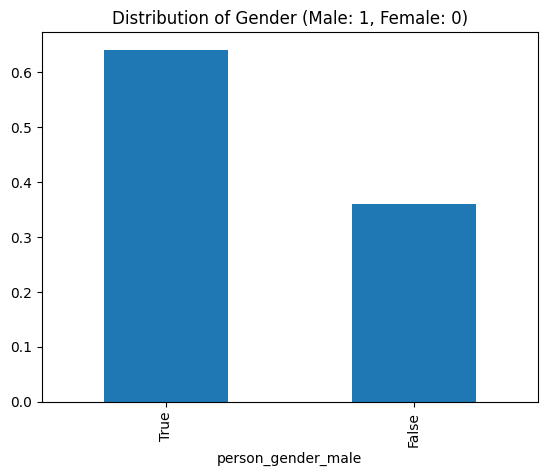

In [ ]:
df_credit['person_gender_male'].value_counts(normalize=True).plot(kind='bar', title='Distribution of Gender (Male: 1, Female: 0)')

In [ ]:
!pip install imbalanced-learn

In [ ]:
print("Distribución original:")
print(df_credit["loan_status"].value_counts())

#Separar variables
X = df_credit.drop("loan_status", axis=1)
y = df_credit["loan_status"]

categorical_cols = X.select_dtypes(include='object').columns

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

#Aplicar SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

#Reconstruir dataframe balanceado
df_credit = pd.DataFrame(X_resampled, columns=X.columns)
df_credit["loan_status"] = y_resampled

#Verificar resultado
print("\nDistribución después de SMOTE:")
print(df_credit["loan_status"].value_counts())

Distribución original:
loan_status
0    35000
1    10000
Name: count, dtype: int64

Distribución después de SMOTE:
loan_status
1    35000
0    35000
Name: count, dtype: int64


In [ ]:
df_credit["credit_score"].describe()

,credit_score
count,70000.000000
mean,632.424429
std,47.340891
min,390.000000
25%,603.000000
50%,638.000000
75%,667.000000
max,850.000000


In [ ]:
df_credit["loan_amnt"].describe()

,loan_amnt
count,69985.000000
mean,10021.186830
std,6623.847128
min,500.000000
25%,5000.000000
50%,8462.864595
75%,14000.000000
max,35000.000000


In [ ]:
df_credit[df_credit["person_age"]>70]["person_age"]

,person_age
81,144.0
183,144.0
575,123.0
747,123.0
32297,144.0
32355,78.0
32381,73.0
32416,94.0
32422,80.0
32432,73.0


In [ ]:
df_credit = df_credit.drop(df_credit[df_credit["person_age"]>70].index)

In [ ]:
target_column = "loan_status"

x = df_credit.drop(target_column, axis=1)
y = df_credit[target_column]

x = pd.get_dummies(x, drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
df_mesclado = pd.concat([x, y], axis=1).sample(frac=1, ramdon_state=42).reset_index(drop=True)

train_df = df_mesclado.iloc[:500]
test_df = df_mesclado.iloc[:500]

x_train = train_df.drop(target_column, axis=1)
y_train = train_df[target_column]

x_test = test_df.drop(target_column, axis=1)
y_test = test_df

print("Filas de entrenamiento:", len(x_train))
print("Filas de prueba:", len(x_test))

rf_classifier = RandomForestClassifier(random_state=42)

rf_classifier.fit(x_train, y_train)

y_pred = rf_classifier.predict(x_test)

print("\nResultados:")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))


Filas de entrenamiento: 55988
Filas de prueba: 13997

Resultados:
Accuracy: 0.945488318925484
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      6997
           1       0.94      0.95      0.95      7000

    accuracy                           0.95     13997
   macro avg       0.95      0.95      0.95     13997
weighted avg       0.95      0.95      0.95     13997



In [ ]:
nuevo_cliente_processed = pd.DataFrame(0, index=[0], columns=x_train.columns)

nuevo_cliente_processed['person_age'] = 35
nuevo_cliente_processed['person_income'] = 10000
nuevo_cliente_processed['credit_score'] = 632
nuevo_cliente_processed['loan_amnt'] = 10

probabilidad = rf_classifier.predict_proba(nuevo_cliente_processed)[:,1]
prediccion = rf_classifier.predict(nuevo_cliente_processed)

print("Probabilidad de aprobación:", probabilidad)
print("Decisión:", prediccion)

Probabilidad de aprobación: [0.42]
Decisión: [0]


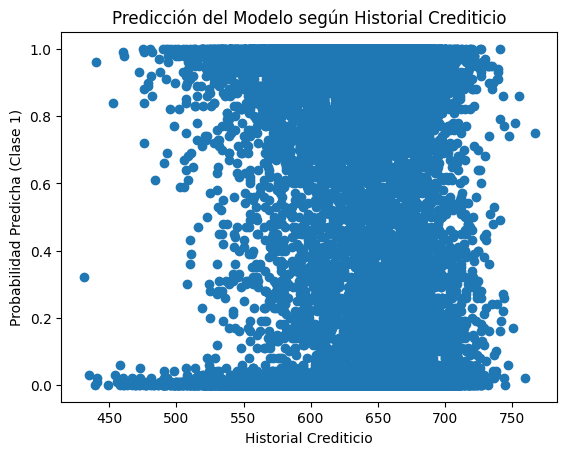

In [ ]:
import matplotlib.pyplot as plt

# Obtener probabilidades de clase 1
y_proba = rf_classifier.predict_proba(x_test)[:, 1]

# Variable historial
historial = x_test['credit_score']

plt.figure()
plt.scatter(historial, y_proba)
plt.xlabel("Historial Crediticio")
plt.ylabel("Probabilidad Predicha (Clase 1)")
plt.title("Predicción del Modelo según Historial Crediticio")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

n_clientes = 50
clientes = []

for i in range(n_clientes):

    nuevo_cliente = pd.DataFrame(0, index=[0], columns=x_train.columns)

    # Edad razonable
    edad = np.random.randint(21, 50)

    # Ingreso con límites reales
    ingreso = np.clip(np.random.normal(7000, 1500), 8000, 15000)

    # Credit score realista (300–850)
    credit_score = np.clip(np.random.normal(632, 50), 500, 850)

    # Loan amount coherente con ingreso (máximo 50% ingreso anual)
    loan_amnt = np.random.randint(500, int(ingreso * 0.2))

    nuevo_cliente['person_age'] = edad
    nuevo_cliente['person_income'] = ingreso
    nuevo_cliente['credit_score'] = credit_score
    nuevo_cliente['loan_amnt'] = loan_amnt

    if 'previous_loan_defaults_on_file_True' in x_train.columns:
        nuevo_cliente['previous_loan_defaults_on_file_True'] = np.random.choice([0,1], p=[0.7,0.3])

    if 'person_gender_male' in x_train.columns:
        nuevo_cliente['person_gender_male'] = np.random.choice([0,1])

    clientes.append(nuevo_cliente)

clientes_df = pd.concat(clientes, ignore_index=True)

prob_rechazo = rf_classifier.predict_proba(clientes_df)[:,1]
predicciones = rf_classifier.predict(clientes_df)

clientes_df['probabilidad_rechazo'] = prob_rechazo
clientes_df['resultado'] = pd.Series(predicciones).map({0:'Aprobado', 1:'Rechazado'})

print(clientes_df[['person_age',
                   'person_income',
                   'credit_score',
                   'loan_amnt',
                   'probabilidad_rechazo',
                   'resultado']])

    person_age  person_income  credit_score  loan_amnt  probabilidad_rechazo  \
0           23    8602.707331    645.920663       1133                  0.48   
1           30    9177.539138    621.752142        797                  0.43   
2           36    9111.661143    655.518299       1440                  0.48   
3           42    8000.000000    655.996859       1470                  0.52   
4           28    8000.000000    648.498280       1016                  0.50   
5           46    8000.000000    600.149360        724                  0.49   
6           22    9698.094706    568.141133        900                  0.50   
7           39    8000.000000    550.439325       1188                  0.49   
8           43    8000.000000    583.540114        878                  0.50   
9           43    8000.000000    755.085409       1151                  0.47   
10          46   10256.830866    675.485790       1771                  0.48   
11          49    8253.790861    662.967

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# =========================
# 1. Separar variable objetivo
# =========================
target_column = "loan_status"

X = df_credit.drop(target_column, axis=1)
y = df_credit[target_column]

# Convertir variables categóricas
X = pd.get_dummies(X, drop_first=True)

# =========================
# 2. Mezclar dataset
# =========================
df_shuffled = pd.concat([X, y], axis=1).sample(frac=1, random_state=42).reset_index(drop=True)

# =========================
# 3. Tomar 500 filas para entrenamiento
# =========================
train_df = df_shuffled.iloc[:500]
test_df = df_shuffled.iloc[500:]

X_train = train_df.drop(target_column, axis=1)
y_train = train_df[target_column]

X_test = test_df.drop(target_column, axis=1)
y_test = test_df[target_column]

# =========================
# 4. Escalado para KNN
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# MODELO 1: Random Forest
# =========================
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== RANDOM FOREST ===")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# =========================
# MODELO 2: Decision Tree
# =========================
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("\n=== DECISION TREE ===")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

# =========================
# MODELO 3: KNN
# =========================
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

print("\n=== KNN ===")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

=== RANDOM FOREST ===
Accuracy: 0.8936748938619846
              precision    recall  f1-score   support

           0       0.88      0.91      0.89     34726
           1       0.90      0.88      0.89     34759

    accuracy                           0.89     69485
   macro avg       0.89      0.89      0.89     69485
weighted avg       0.89      0.89      0.89     69485


=== DECISION TREE ===
Accuracy: 0.8339497733323739
              precision    recall  f1-score   support

           0       0.82      0.85      0.84     34726
           1       0.85      0.81      0.83     34759

    accuracy                           0.83     69485
   macro avg       0.83      0.83      0.83     69485
weighted avg       0.83      0.83      0.83     69485


=== KNN ===
Accuracy: 0.8499244441246312
              precision    recall  f1-score   support

           0       0.84      0.86      0.85     34726
           1       0.86      0.84      0.85     34759

    accuracy                         